# Experiment 1: LSTM-Only Baseline

Standalone LSTM model for direct comparison with graph-based models.
No graph layer — pure temporal modelling per stock.

**Architecture:** LSTM -> Dropout -> TimeDistributed(Dense(1, tanh))
**Data:** Per-ticker sliding windows (3D), NOT stacked across tickers (4D)
**Loss:** SharpeLoss (same as graph models)
**Evaluation:** Extract last timestep, aggregate across stocks by date

## 1. Setup

In [73]:
!pip install -q tensorflow>=2.16.0 keras-tuner empyrical-reloaded spektral

In [74]:
import os, sys
if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/repo'):
        !git clone https://github.com/adam-909/4yp.git /content/repo
    else:
        !cd /content/repo && git pull
    os.chdir('/content/repo/4YP-main')
else:
    os.chdir('/home/adam/new4YP/4YP-main')
sys.path.insert(0, os.getcwd())
print(f"Working directory: {os.getcwd()}")

Already up to date.
Working directory: /content/repo/4YP-main


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from empyrical import sharpe_ratio, sortino_ratio, max_drawdown, annual_return, annual_volatility, calmar_ratio
import random, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 2. Configuration

In [76]:
EXPERIMENT_NAME = "1_lstm_only_"
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

TRAIN_START = 2011
TEST_START = 2017
TEST_END = 2023
VOL_TARGET = 0.15

# Model Configuration
TOTAL_TIME_STEPS = 20
TRAIN_VALID_RATIO = 0.8
NUM_EPOCHS = 300
EARLY_STOPPING_PATIENCE = 25

# LSTM Hyperparameters
HIDDEN_LAYER_SIZE = 10
DROPOUT_RATE = 0.3
LEARNING_RATE = 0.001
MAX_GRADIENT_NORM = 0.01
BATCH_SIZE = 64

if 'google.colab' in str(get_ipython()):
    from google.colab import drive
    drive.mount('/content/drive')
    RESULTS_BASE = "/content/drive/MyDrive/FINAL_RESULTS"
else:
    RESULTS_BASE = "FINAL_RESULTS"

print(f"Experiment: {EXPERIMENT_NAME} (seed={SEED})")
print(f"Train: {TRAIN_START}-{TEST_START}, Test: {TEST_START}-{TEST_END}")
print(f"LSTM hidden: {HIDDEN_LAYER_SIZE}, dropout: {DROPOUT_RATE}")
print(f"LR: {LEARNING_RATE}, clip: {MAX_GRADIENT_NORM}, batch: {BATCH_SIZE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Experiment: 1_lstm_only_ (seed=42)
Train: 2011-2017, Test: 2017-2023
LSTM hidden: 10, dropout: 0.3
LR: 0.001, clip: 0.01, batch: 64


## 3. Helper Functions

In [77]:
def calc_daily_returns(df, returns_col="captured_returns"):
    num_tickers = df["identifier"].nunique()
    daily_ret = df.groupby("time")[returns_col].sum() / num_tickers
    daily_ret.index = pd.to_datetime(daily_ret.index)
    return daily_ret.sort_index()

def calc_vol_scaled_returns(daily_returns, target_vol=0.15):
    current_vol = daily_returns.std() * np.sqrt(252)
    return daily_returns * (target_vol / current_vol) if current_vol > 0 else daily_returns

def calc_metrics(daily_returns, name="Strategy"):
    return {"Strategy": name, "E[Ret.]": annual_return(daily_returns),
        "Vol.": annual_volatility(daily_returns), "Sharpe": sharpe_ratio(daily_returns),
        "Sortino": sortino_ratio(daily_returns), "Max DD": -max_drawdown(daily_returns),
        "Calmar": calmar_ratio(daily_returns), "Hit Rate": (daily_returns > 0).mean(),
        "Avg P/L": daily_returns[daily_returns > 0].mean() / abs(daily_returns[daily_returns < 0].mean()) if (daily_returns < 0).any() else np.nan}

def calc_metrics_vol_normalized(daily_returns, name, target_vol=0.15):
    scaled = calc_vol_scaled_returns(daily_returns, target_vol)
    return calc_metrics(scaled, name + " (Vol-Norm)"), scaled

def display_metrics(m):
    df = pd.DataFrame([m]).set_index("Strategy")
    for c in ["E[Ret.]","Vol.","Max DD","Hit Rate"]:
        if c in df.columns: df[c] = df[c].apply(lambda x: f"{x:.2%}")
    for c in ["Sharpe","Sortino","Calmar","Avg P/L"]:
        if c in df.columns: df[c] = df[c].apply(lambda x: f"{x:.3f}")
    display(df)

def calc_yearly_sharpes(daily_returns):
    return {y: sharpe_ratio(daily_returns[daily_returns.index.year == y]) for y in sorted(daily_returns.index.year.unique())}

def plot_results(daily_returns_dict, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = plt.cm.tab10(np.linspace(0, 1, len(daily_returns_dict)))
    for (n, r), c in zip(daily_returns_dict.items(), colors):
        axes[0,0].plot(((1+r).cumprod()-1).index, ((1+r).cumprod()-1).values, label=n, lw=1.5, color=c)
        cum = (1+r).cumprod(); dd = (cum - cum.cummax()) / cum.cummax()
        axes[0,1].fill_between(dd.index, dd.values, 0, alpha=0.3, label=n, color=c)
        rs = r.rolling(252).mean() / r.rolling(252).std() * np.sqrt(252)
        axes[1,0].plot(rs.index, rs.values, label=n, lw=1, color=c)
    axes[0,0].set_title("Cumulative Returns"); axes[0,0].legend(fontsize=8); axes[0,0].grid(True, alpha=0.3)
    axes[0,1].set_title("Drawdown"); axes[0,1].legend(fontsize=8); axes[0,1].grid(True, alpha=0.3)
    axes[1,0].axhline(y=0, color="black", ls="--", lw=0.5); axes[1,0].set_title("Rolling Sharpe"); axes[1,0].legend(fontsize=8); axes[1,0].grid(True, alpha=0.3)
    yd = pd.DataFrame({n: calc_yearly_sharpes(r) for n,r in daily_returns_dict.items()})
    yd.plot(kind="bar", ax=axes[1,1], width=0.8); axes[1,1].axhline(y=0, color="black", ls="--", lw=0.5)
    axes[1,1].set_title("Yearly Sharpe"); axes[1,1].tick_params(axis="x", rotation=45); axes[1,1].grid(True, alpha=0.3, axis="y")
    plt.suptitle(title, fontsize=14, fontweight="bold"); plt.tight_layout(); plt.show()

## 4. Data Loading

In [78]:
features_path = "data/straddle_features/features.csv"
if 'google.colab' in str(get_ipython()):
    features_path = "/content/drive/MyDrive/features.csv"

df = pd.read_csv(features_path)
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
print(f"Loaded {len(df)} rows, {df['ticker'].nunique()} tickers")

Loaded 274384 rows, 88 tickers


In [79]:
from gml.model_inputs import ModelFeatures

features = ModelFeatures(
    df=df,
    total_time_steps=TOTAL_TIME_STEPS,
    start_boundary=TRAIN_START,
    test_boundary=TEST_START,
    test_end=TEST_END,
    train_valid_ratio=TRAIN_VALID_RATIO,
    split_tickers_individually=True,
    time_features=False,
)

print(f"Training: inputs={features.train['inputs'].shape}")
print(f"Validation: inputs={features.valid['inputs'].shape}")
print(f"Test (sliding): inputs={features.test_sliding['inputs'].shape}")
print(f"Note: 3D data (N_samples, {TOTAL_TIME_STEPS}, {features.train['inputs'].shape[-1]})")
print(f"Samples are per-ticker sliding windows, concatenated across all tickers")

no lags


train _batch
len(data_map[k]): 88
len(data_map[k]): 88
len(data_map[k]): 88
len(data_map[k]): 88
len(data_map[k]): 88
inputs.shape: (5104, 20, 10)
outputs.shape: (5104, 20, 1)
active_entries.shape: (5104, 20)


valid _batch
len(data_map[k]): 88
len(data_map[k]): 88
len(data_map[k]): 88
len(data_map[k]): 88
len(data_map[k]): 88
inputs.shape: (1320, 20, 10)
outputs.shape: (1320, 20, 1)
active_entries.shape: (1320, 20)


test _batch
len(data_map[k]): 88
len(data_map[k]): 88
len(data_map[k]): 88
len(data_map[k]): 88
len(data_map[k]): 88
inputs.shape: (6160, 20, 10)
outputs.shape: (6160, 20, 1)
active_entries.shape: (6160, 20)


test sliding _batch
inputs.shape: (123200, 20, 10)
outputs.shape: (123200, 20, 1)
active_entries.shape: (123200, 20)
Training: inputs=(5104, 20, 10)
Validation: inputs=(1320, 20, 10)
Test (sliding): inputs=(123200, 20, 10)
Note: 3D data (N_samples, 20, 10)
Samples are per-ticker sliding windows, concatenated across all tickers


## 5. Model Definition

In [80]:
from gml.deep_neural_network import SharpeLoss

input_size = features.train["inputs"].shape[-1]

print(f"Building LSTM-only model:")
print(f"  input_size: {input_size}")
print(f"  LSTM hidden: {HIDDEN_LAYER_SIZE}")

input_layer = keras.Input(shape=(TOTAL_TIME_STEPS, input_size))
x = layers.LSTM(
    HIDDEN_LAYER_SIZE,
    return_sequences=True,
    dropout=DROPOUT_RATE,
    activation="tanh",
    recurrent_activation="sigmoid",
)(input_layer)
x = layers.Dropout(DROPOUT_RATE)(x)
output = layers.TimeDistributed(
    layers.Dense(1, activation="tanh", kernel_constraint=keras.constraints.max_norm(3))
)(x)

model = keras.Model(inputs=input_layer, outputs=output)
adam = keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=MAX_GRADIENT_NORM)
model.compile(loss=SharpeLoss(output_size=1), optimizer=adam)

print(f"Total parameters: {model.count_params():,}")
model.summary()

Building LSTM-only model:
  input_size: 10
  LSTM hidden: 10
Total parameters: 851


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 20, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 20, 10)         │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 20, 1)          │            11 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851 (3.32 KB)

 Trainable params: 851 (3.32 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Training

In [81]:
X_train = features.train["inputs"]
y_train = features.train["outputs"]
w_train = features.train["active_entries"]

X_valid = features.valid["inputs"]
y_valid = features.valid["outputs"]
w_valid = features.valid["active_entries"]

print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_valid.shape[0]}")

Training samples: 5104
Validation samples: 1320


In [82]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True, verbose=1)

print("=" * 60)
print(f"Training {EXPERIMENT_NAME} (seed={SEED})")
print(f"  LSTM hidden: {HIDDEN_LAYER_SIZE}, dropout: {DROPOUT_RATE}")
print(f"  LR: {LEARNING_RATE}, clip: {MAX_GRADIENT_NORM}, batch: {BATCH_SIZE}")
print("=" * 60)

history = model.fit(
    X_train, y_train, sample_weight=w_train,
    validation_data=(X_valid, y_valid, w_valid),
    epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stopping], verbose=1,
)

Training 1_lstm_only_ (seed=42)
  LSTM hidden: 10, dropout: 0.3
  LR: 0.001, clip: 0.01, batch: 64
Epoch 1/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: -0.4403 - val_loss: -0.8130
Epoch 2/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: -0.6104 - val_loss: -0.9008
Epoch 3/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: -0.6203 - val_loss: -0.9073
Epoch 4/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: -0.6723 - val_loss: -0.9232
Epoch 5/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: -0.6883 - val_loss: -0.9393
Epoch 6/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: -0.6919 - val_loss: -0.9415
Epoch 7/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: -0.7082 - val_loss: -0.9498
Epoch 8/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: -0.7285 - val_loss: -0.9597
Epoch 9/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: -0.7128 - val_loss: -0.9631
Epoch 10/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: -0.7183 - val_loss: -0.9660
Epoch 11/300
80/80 ━━━━━━

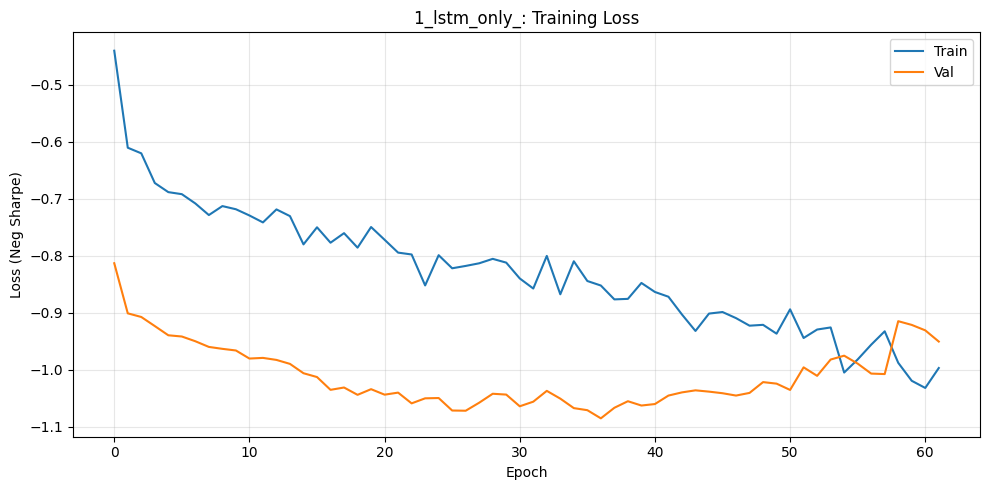

Epochs: 62, Best val: -1.0850


In [83]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.xlabel("Epoch"); plt.ylabel("Loss (Neg Sharpe)")
plt.title(f"{EXPERIMENT_NAME}: Training Loss")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print(f"Epochs: {len(history.history['loss'])}, Best val: {min(history.history['val_loss']):.4f}")

## 7. Evaluation

In [84]:
# Use test_sliding for evaluation (stride=1, same as graph models)
test_data = features.test_sliding

X_test = test_data["inputs"]
predictions = model.predict(X_test)
print(f"Predictions shape: {predictions.shape}")

3850/3850 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step
Predictions shape: (123200, 20, 1)


In [85]:
# Extract last timestep only (same as graph models)
positions = predictions[:, -1, 0]
returns_test = test_data["outputs"][:, -1, 0]
captured_returns = positions * returns_test

dates = test_data["date"][:, -1, 0]
identifiers = test_data["identifier"][:, -1, 0]

results_df = pd.DataFrame({
    "time": dates, "identifier": identifiers,
    "position": positions, "returns": returns_test,
    "captured_returns": captured_returns,
})
results_df["time"] = pd.to_datetime(results_df["time"])
results_df = results_df[results_df["identifier"] != "0"]
print(f"Results: {len(results_df)} rows")
results_df.head()

Results: 123200 rows


,time,identifier,position,returns,captured_returns
0,2017-01-03,AAPL,-0.002626,-0.009874,0.000026
1,2017-01-04,AAPL,0.185579,0.005800,0.001076
2,2017-01-05,AAPL,0.320580,0.021548,0.006908
3,2017-01-06,AAPL,0.217938,-0.000596,-0.000130
4,2017-01-10,AAPL,-0.028082,-0.000210,0.000006


In [86]:
daily_returns = calc_daily_returns(results_df)

print("" + "=" * 60)
print(f"{EXPERIMENT_NAME} Results (Raw)")
print("=" * 60)
metrics_raw = calc_metrics(daily_returns, EXPERIMENT_NAME)
display_metrics(metrics_raw)

print(f"Vol-Normalized (Target: {VOL_TARGET:.0%})")
metrics_norm, _ = calc_metrics_vol_normalized(daily_returns, EXPERIMENT_NAME, VOL_TARGET)
display_metrics(metrics_norm)

print("Yearly Sharpes:")
yearly_sharpes = calc_yearly_sharpes(daily_returns)
for y, s in yearly_sharpes.items(): print(f"  {y}: {s:.4f}")

1_lstm_only_ Results (Raw)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
1_lstm_only_,3.95%,3.78%,1.044,1.423,5.90%,0.670,60.29%,0.809


Vol-Normalized (Target: 15%)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
1_lstm_only_ (Vol-Norm),15.64%,15.00%,1.044,1.423,22.01%,0.711,60.29%,0.809


Yearly Sharpes:
  2017: 3.5742
  2018: -0.1640
  2019: 2.7758
  2020: 0.3890
  2021: 1.4016
  2022: 0.5794


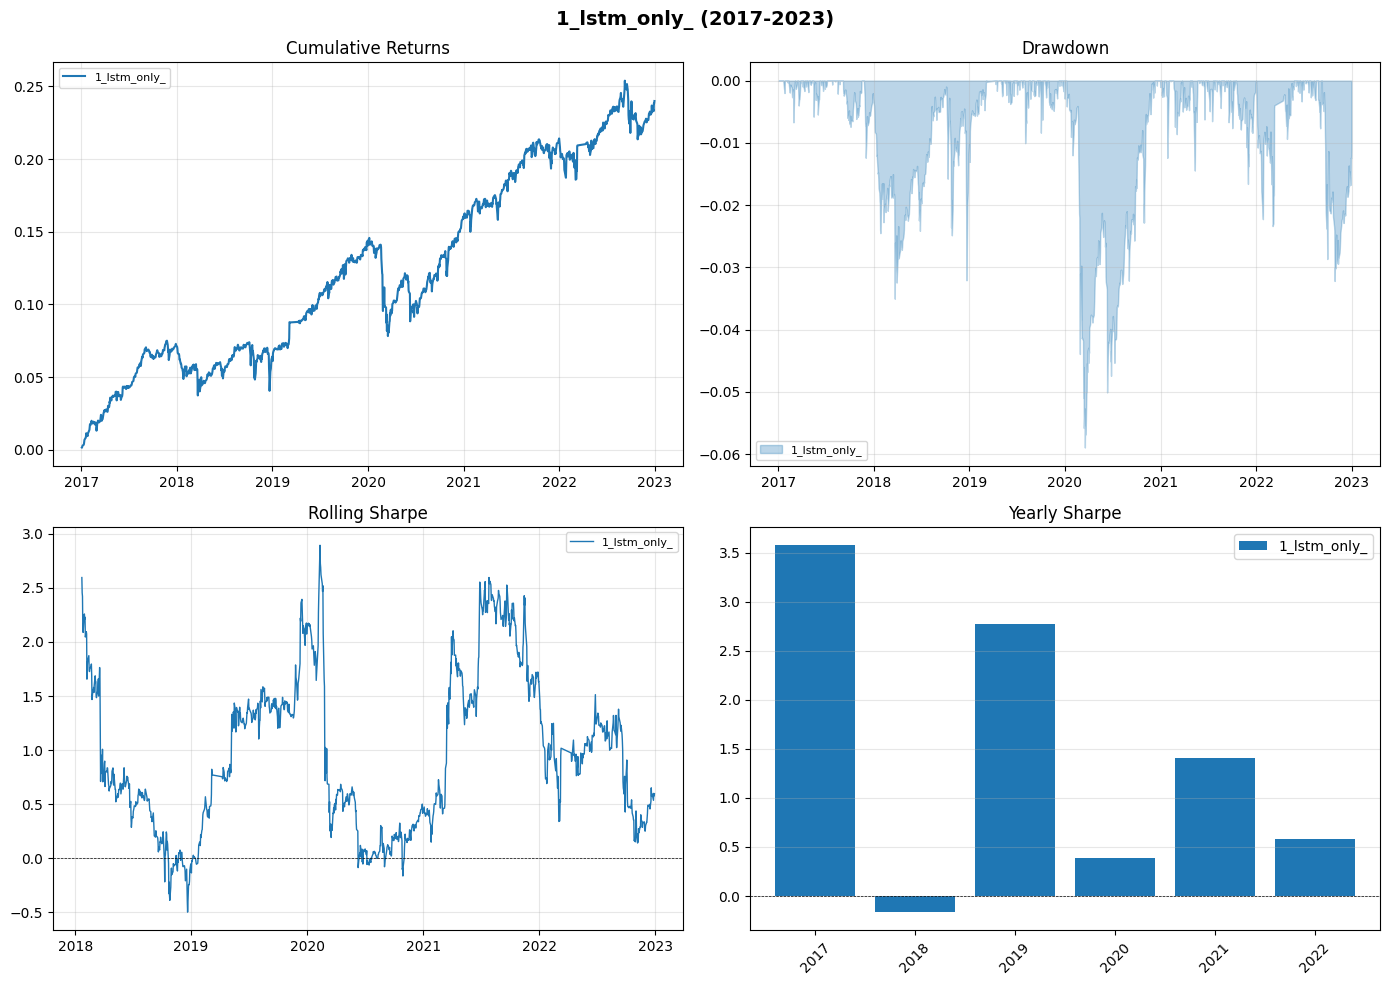

In [87]:
plot_results({EXPERIMENT_NAME: daily_returns}, f"{EXPERIMENT_NAME} ({TEST_START}-{TEST_END})")

## 8. Position Analysis

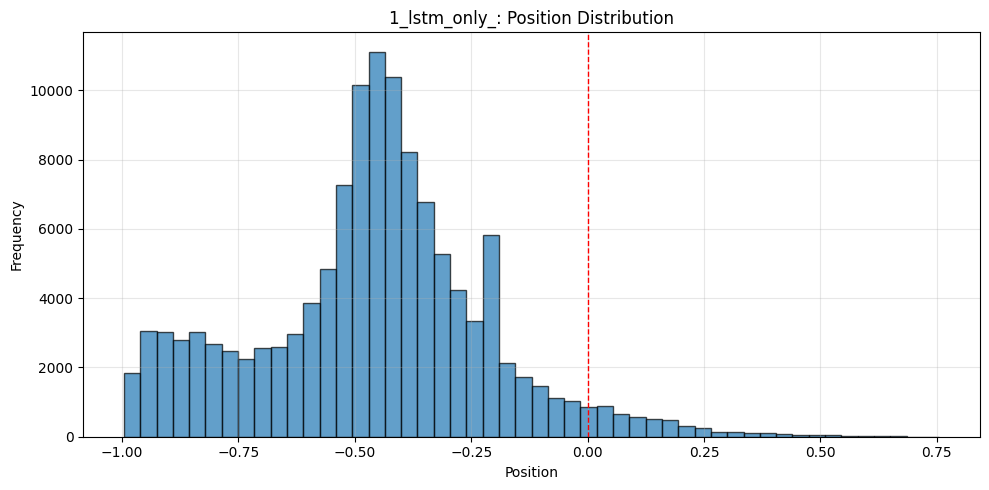

In [88]:
plt.figure(figsize=(10, 5))
plt.hist(results_df["position"], bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Position"); plt.ylabel("Frequency")
plt.title(f"{EXPERIMENT_NAME}: Position Distribution")
plt.axvline(x=0, color="red", ls="--", lw=1); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 9. Save Results

In [89]:
from gml.experiment_utils import save_experiment_results

hyperparams = {
    "hidden_layer_size": HIDDEN_LAYER_SIZE,
    "dropout_rate": DROPOUT_RATE,
    "learning_rate": LEARNING_RATE,
    "max_gradient_norm": MAX_GRADIENT_NORM,
    "batch_size": BATCH_SIZE,
    "model_type": "LSTM_only",
    "total_time_steps": TOTAL_TIME_STEPS,
    "train_valid_ratio": TRAIN_VALID_RATIO,
    "train_start": TRAIN_START,
    "test_start": TEST_START,
    "test_end": TEST_END,
}

# Get test dates for alignment
test_dates_arr = pd.to_datetime(test_data["date"][:, -1, 0])

save_experiment_results(
    experiment_name=EXPERIMENT_NAME, seed=SEED,
    predictions=predictions, results_df=results_df,
    daily_returns=daily_returns, metrics_raw=metrics_raw,
    metrics_norm=metrics_norm, yearly_sharpes=yearly_sharpes,
    training_history=history.history, hyperparams=hyperparams,
    test_dates=test_dates_arr.values,
    model=model,
    base_dir=RESULTS_BASE,
)

Results saved to: /content/drive/MyDrive/FINAL_RESULTS/1_lstm_only_/seed_42
Saved 10 files:
  captured_returns_sw.csv (8.0 MB)
  metrics_raw.csv (237 B)
  metrics_vol_normalized.csv (245 B)
  yearly_sharpes.csv (158 B)
  daily_returns.csv (45.5 KB)
  training_history.json (3.0 KB)
  hyperparams.json (275 B)
  predictions.npy (9.4 MB)
  test_dates.npy (962.6 KB)
  model_weights/weights.weights.h5 (36.3 KB)


## 10. Summary

In [90]:
print("=" * 60)
print(f"EXPERIMENT: {EXPERIMENT_NAME} (seed={SEED})")
print("=" * 60)
print(f"Model: LSTM-only (no graph layer)")
print(f"LSTM hidden: {HIDDEN_LAYER_SIZE}, dropout: {DROPOUT_RATE}")
print(f"LR: {LEARNING_RATE}, clip: {MAX_GRADIENT_NORM}, batch: {BATCH_SIZE}")
print(f"Sharpe: {metrics_raw['Sharpe']:.3f}, Return: {metrics_raw['E[Ret.]']:.2%}, Vol: {metrics_raw['Vol.']:.2%}")
print(f"Saved to: {RESULTS_BASE}/{EXPERIMENT_NAME}/seed_{SEED}/")

EXPERIMENT: 1_lstm_only_ (seed=42)
Model: LSTM-only (no graph layer)
LSTM hidden: 10, dropout: 0.3
LR: 0.001, clip: 0.01, batch: 64
Sharpe: 1.044, Return: 3.95%, Vol: 3.78%
Saved to: /content/drive/MyDrive/FINAL_RESULTS/1_lstm_only_/seed_42/
